## The Data

At this link, you will find a dataset containing information about heart disease patients: https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1

A description of the original dataset can be found here: https://archive.ics.uci.edu/dataset/45/heart+disease (However, this dataset has been cleaned and reduced, and the people have been given fictious names.)

In [70]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from plotnine import *
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import root_mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [34]:
#read in data
ha = pd.read_csv("https://www.dropbox.com/scl/fi/0vrpdnq5asmeulc4gd50y/ha_1.csv?rlkey=ciisalceotl77ffqhqe3kujzv&dl=1")
ha.head()


,Name,age,sex,cp,trtbps,chol,restecg,thalach,diagnosis
0,Magnolia Cassin,60,1,1,117,230,1,160,No Disease
1,Dr. Cathern Heathcote,60,0,3,102,318,1,160,Disease
2,Miles Wolf,62,0,3,130,263,1,97,No Disease
3,Mikaila Block,43,1,1,115,303,1,181,Disease
4,Mrs. Jacquline Marquardt,66,1,1,120,302,0,151,Disease


In [4]:
ha.dtypes

,0
Name,object
age,int64
sex,int64
cp,int64
trtbps,int64
chol,int64
restecg,int64
thalach,int64
diagnosis,object


In [35]:
ha['diagnosis'] = ha['diagnosis'].map({
    "Disease":1,
    "No Disease":0
})

ha.head()

,Name,age,sex,cp,trtbps,chol,restecg,thalach,diagnosis
0,Magnolia Cassin,60,1,1,117,230,1,160,0
1,Dr. Cathern Heathcote,60,0,3,102,318,1,160,1
2,Miles Wolf,62,0,3,130,263,1,97,0
3,Mikaila Block,43,1,1,115,303,1,181,1
4,Mrs. Jacquline Marquardt,66,1,1,120,302,0,151,1


In [36]:
X = ha[['age', 'chol']]
y = ha['diagnosis']

In [37]:
X.head()

,age,chol
0,60,230
1,60,318
2,62,263
3,43,303
4,66,302


In [38]:
y.head()

,diagnosis
0,0
1,1
2,0
3,1
4,1


## 1. Logistic Regression

Fit a Logistic Regression using only `age` and `chol` (cholesterol) as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

How high for the doctors to estimate a 90% chance that heart disease is present?

In [42]:
#fit logistic regression
logit_pipeline = Pipeline([
    ("stdz", StandardScaler()),
    ("logit", LogisticRegression(random_state = 321))
])

logit_fitted = logit_pipeline.fit(X, y)
logit_fitted.named_steps["logit"].coef_, logit_fitted.named_steps["logit"].intercept_

(array([[-0.42746115, -0.09597543]]), array([0.27025982]))

In [44]:
#standardize age 55
std_age = (55 - ha['age'].mean())/ha['age'].std()
std_age

np.float64(0.1268094358001019)

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?:

Our logistic regression model is:

$log(\frac{p}{1-p}) = 0.270-0.427(age)-0.096(chol)$

Say we choose a cutoff value of p = 0.5. Then, $log(\frac{p}{1-p}) = 0$. So, we can solve for cholesterol:

$0 = 0.270-0.427(age)-0.096(chol)$

$-0.270+0.427(age)=-0.096(chol)$

$chol = \frac{-0.270+0.427(0.127)}{-0.0018}$

In [61]:
logit_intercept = logit_fitted.named_steps["logit"].intercept_
logit_age_coef = logit_fitted.named_steps["logit"].coef_[0][0]
logit_chol_coef = logit_fitted.named_steps["logit"].coef_[0][1]

chol_std = -(logit_intercept+(logit_age_coef*std_age))/logit_chol_coef
chol_std

array([2.25113576])

In [62]:
chol_unstd = chol_std*ha['chol'].std()+ha['chol'].mean()
chol_unstd

array([368.08525191])

The cholesterol for a 55 year old would need to be at least 368.085 mg/dl for the doctors to predict heart disease is present.

How high for the doctors to estimate a 90% chance that heart disease is present?:

if p = 0.9, our equation becomes:

$log(\frac{0.9}{0.1}) = 0.270-0.427(age)-0.096(chol)$

$log(9) = 0.270-0.427(age)-0.096(chol)$

$log(9)-0.270+0.427(age)=-0.096(chol)$

$chol = \frac{log(9)-0.270+0.427(0.127)}{-0.096}$

In [63]:
chol_std = (np.log(9)-logit_intercept-(logit_age_coef*std_age))/logit_chol_coef
chol_std

array([-20.6424805])

In [64]:
chol_unstd = chol_std*ha['chol'].std()+ha['chol'].mean()
chol_unstd

array([-849.31998079])

The cholesterol for a 55 year old would need to be at least -849.32 mg/dl for the doctors to estimate a 90% chance heart disease is present.

## 2. Linear Discriminant Analysis

Fit an LDA model using only `age` and `chol` (cholesterol)  as predictors.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [65]:
#n_components = 1 indicates there is only one direction in feature space (a line) that matters for separating age and cholesterol
lda_pipeline = Pipeline([
    ("stdz", StandardScaler()),
    ("lda", LinearDiscriminantAnalysis(n_components=1))
]) #max n_components = num predictors - 1

lda_fitted = lda_pipeline.fit(X, y)
lda_fitted.named_steps["lda"].coef_, lda_fitted.named_steps["lda"].intercept_

(array([[-0.43446582, -0.09493491]]), array([0.26973565]))

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?:

Our LDA model is:

$z_i = 0.2697-0.434(age)-0.0949(chol)$

Our decision boundary is $z_i = 0$. So, we can solve for cholesterol:

$0 = 0.2697-0.434(age)-0.0949(chol)$

$-0.2697+0.434(age)=-0.0949(chol)$

$chol = \frac{-0.2697+0.434(age)}{-0.0949}$

In [66]:
lda_intercept = lda_fitted.named_steps["lda"].intercept_
lda_coef_age = lda_fitted.named_steps["lda"].coef_[0][0]
lda_coef_chol = lda_fitted.named_steps["lda"].coef_[0][1]

chol_std = -(lda_intercept+(lda_coef_age*std_age))/lda_coef_chol
chol_std

array([2.26093099])

In [67]:
chol_unstd = chol_std*ha['chol'].std()+ha['chol'].mean()
chol_unstd

array([368.60612891])

The cholesterol for a 55 year old would need to be at least 368.606 mg/dl for the doctors to predict heart disease is present.

## 3. Support Vector Classifier

Fit an SVC model using only `age` and `chol` as predictors.  Don't forget to tune the regularization parameter.

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?

In [73]:
svc_pipeline = Pipeline([
    ("stdz", StandardScaler()),
    ("svc", SVC(kernel='linear', random_state=321, probability = True)) #linear kernel because of only 2 predictors
])

param_grid = {'svc__C':[0.01, 0.1, 1, 10, 100]}

gscv = GridSearchCV(svc_pipeline, param_grid, cv = 5, scoring='neg_root_mean_squared_error')
gscv.fit(X, y)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('stdz', StandardScaler()),
                                       ('svc',
                                        SVC(kernel='linear', probability=True,
                                            random_state=321))]),
             param_grid={'svc__C': [0.01, 0.1, 1, 10, 100]},
             scoring='neg_root_mean_squared_error')

In [74]:
print("Best RMSE:", gscv.best_score_)
print("Best params:", gscv.best_params_)

Best RMSE: -0.6331131172668077
Best params: {'svc__C': 10}


In [76]:
svc_pipeline_final = Pipeline([
    ("stdz", StandardScaler()),
    ("svc", SVC(kernel='linear', random_state=321, probability = True, C = 10)) #linear kernel because of only 2 predictors
])

svc_fitted = svc_pipeline_final.fit(X, y)
svc_fitted.named_steps["svc"].coef_, svc_fitted.named_steps["svc"].intercept_

(array([[-0.60125314, -0.19418837]]), array([0.31173804]))

For a 55 year old, how high would their cholesterol need to be for the doctors to predict heart disease is present?:

Our SVC model is:

$z_i = 0.312-0.601(age)-0.194(chol)$

Our decision boundary is $z_i = 0$. So, we can solve for cholesterol:

$0 = 0.312-0.601(age)-0.194(chol)$

$-0.312+0.601(age)=-0.194(chol)$

$chol = \frac{-0.312+0.601(age)}{-0.194}$

In [77]:
svc_intercept = svc_fitted.named_steps["svc"].intercept_
svc_coef_age = svc_fitted.named_steps["svc"].coef_[0][0]
svc_coef_chol = svc_fitted.named_steps["svc"].coef_[0][1]

chol_std = -(svc_intercept+(svc_coef_age*std_age))/svc_coef_chol
chol_std

array([1.21270638])

In [78]:
chol_unstd = chol_std*ha['chol'].std()+ha['chol'].mean()
chol_unstd

array([312.86508261])

The cholesterol for a 55 year old would need to be at least 312.865 mg/dl for the doctors to predict heart disease is present.

## 4. Comparing Decision Boundaries

Make a scatterplot of `age` and `chol`, coloring the points by their true disease outcome.  Add a line to the plot representing the **linear separator** (aka **decision boundary**) for each of the three models above.

In [82]:
ha['diagnosis'] = ha['diagnosis'].astype('object')
ha['age_std'] = (ha['age'] - ha['age'].mean())/ha['age'].std()
ha['chol_std'] = (ha['chol'] - ha['chol'].mean())/ha['chol'].std()

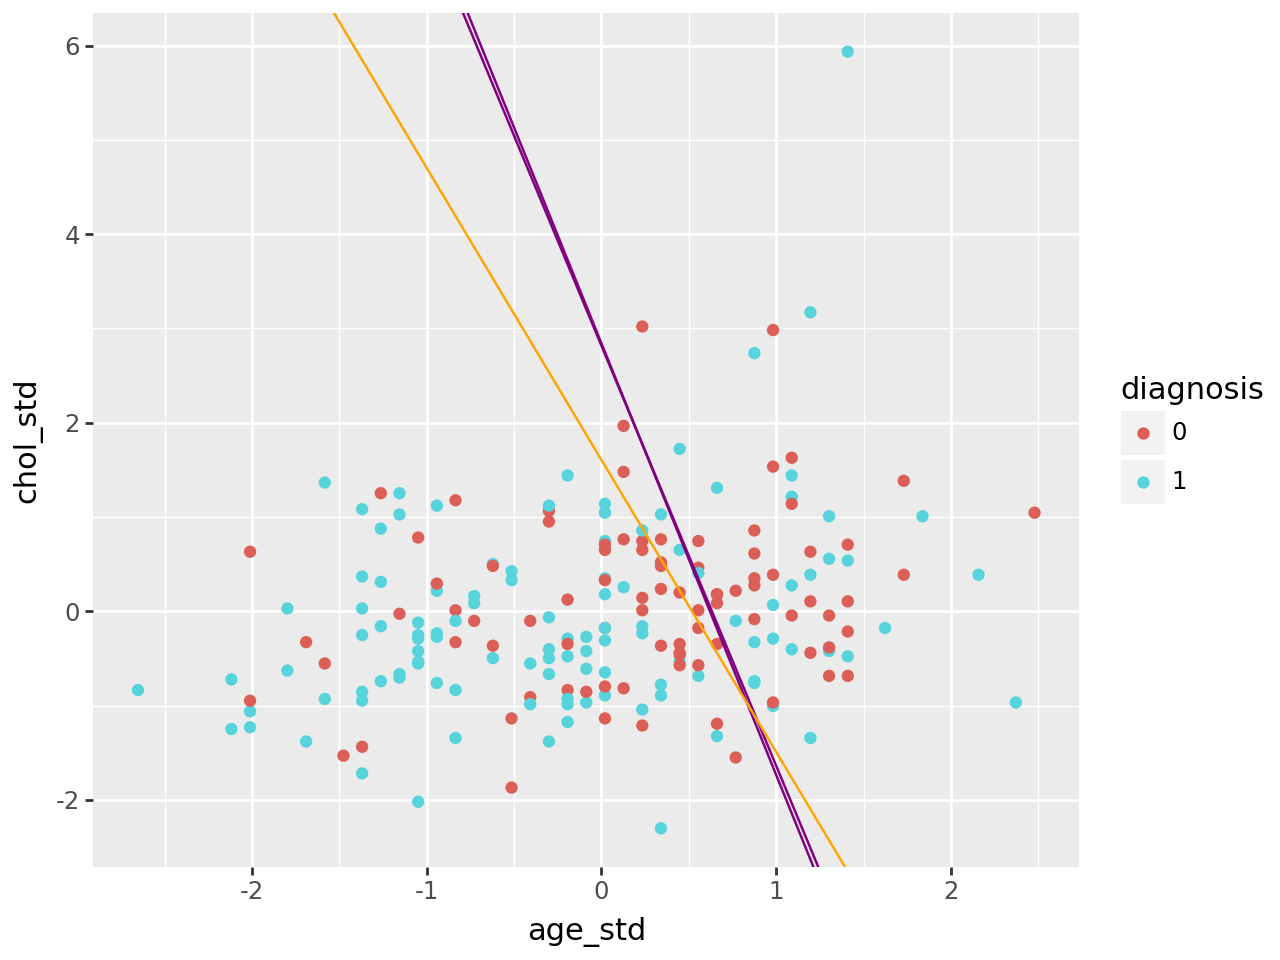

In [84]:
(ggplot(ha,
        aes(
            x = 'age_std',
            y = 'chol_std',
            color = 'diagnosis'
        ))
+ geom_point()
+ geom_abline(intercept = - logit_intercept / logit_chol_coef, slope = - logit_age_coef / logit_chol_coef, color = "purple")
+ geom_abline(intercept = - lda_intercept / lda_coef_chol, slope = - lda_coef_age / lda_coef_chol, color = "purple")
+ geom_abline(intercept = - svc_intercept / svc_coef_chol, slope = - svc_coef_age / svc_coef_chol, color = "orange")
)